In [ ]:
## Loading the drive link in order to retrieve the time-series data

from google.colab import drive
drive.mount('/content/drive')


## identify the type of GPU used, the T4  was used
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

In [ ]:

## Download the packages needed

!pip install cellpose
!pip install stackview
!pip install numpy matplotlib pillow scikit-image tensorflow sklearn opencv-python tifffile seaborn mahotas tqdm InquirerPy yaspin rich termcolor scipy torch

In [ ]:
!pip install mahotas
!pip install InquirerPy
!pip install yaspin
!pip install rich
!pip install scikit-posthocs


In [ ]:
##Download cellpose models

from cellpose import models

print("Downloading nuclei model...")
try:
    nuclei_model = models.CellposeModel(gpu=False, model_type = 'nuclei')
    print("✓ Model downloaded!")
except Exception as e:
    print(f"✗ Error: {e}")

# Verify they're there
import os
from pathlib import Path


cellpose_path = Path.home() / '.cellpose' / 'models'
print(f"\nFiles in {cellpose_path}:")
print(os.listdir(cellpose_path))



In [ ]:
## Recheck everything


from cellpose import version
import torch


print(f"CellPose Version:  {version}")
print(f"Torch Version:  {torch.__version__}")
print(f"GPU available:  {torch.cuda.is_available()}")
print(f"Using GPU:  {torch.cuda.get_device_name(0) if torch.cuda.is_available() else None}")

CellPose Version:  4.0.8
Torch Version:  2.10.0+cu128
GPU available:  True
Using GPU:  Tesla T4


In [ ]:
## Link to data

import os
os.chdir("/content/drive/MyDrive/TESI_MAGISTRALE")

!pwd

/content/drive/MyDrive/TESI_MAGISTRALE


In [ ]:
## This part is facultative, I had some problems with the Cellpose models, thought redownloading them was the right thing to do, it worked

import shutil
from pathlib import Path

# Remove entire CellPose cache directory
cellpose_dir = Path('/root/.cellpose')
if cellpose_dir.exists():
    shutil.rmtree(cellpose_dir)
    print("Cleared entire CellPose cache")

# Recreate the directory
cellpose_dir.mkdir(parents=True, exist_ok=True)



from cellpose import models

# For v4.0.1+, just use CellposeModel without model_type
# It will automatically download the default model
model = models.CellposeModel(gpu=True)
print("Model loaded successfully")

Cleared entire CellPose cache


100%|██████████| 1.15G/1.15G [00:13<00:00, 93.1MB/s]


Model loaded successfully


In [ ]:
from collections import defaultdict
# @title


#### LSTM-only code for the thesis project on Model developing for
#### classification of differentiating and non-differentiating hiPSCs cells in cardiomyocytes




# final update in 05/13/2026




##########################################################################################################################################

######################### Importing multiple libraries
import re
import pandas as pd
import stackview
import time
from ast import List
from doctest import debug
from email import message
from math import isnan
from shutil import which
import time
from tkinter import font
from tracemalloc import start
import numpy as np
import matplotlib.pyplot as plt
import os

from simple_parsing import flag

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # Disable oneDNN optimizations to avoid issues with certain operations

import PIL
import skimage
from sklearn.semi_supervised import LabelSpreading
import tensorflow as tf
import pathlib
import cv2
import tifffile as tiff
import seaborn as sns
import mahotas
import tqdm
import InquirerPy
import pickle
import yaspin
import rich
import scikit_posthocs as sp


from collections import defaultdict
from scipy import stats
from termcolor import colored
from cellpose import models, io, utils, plot
from rich.progress import SpinnerColumn, Progress, TextColumn
from rich.spinner import Spinner, SPINNERS
from yaspin import yaspin
from tqdm import tqdm
from InquirerPy import inquirer, prompt
from skimage.segmentation import watershed
from scipy import ndimage
from skimage import morphology, measure, segmentation
from gc import callbacks
from genericpath import isdir
from tabnanny import verbose
from matplotlib import units
from skimage.measure import label, regionprops, shannon_entropy
from skimage.filters import threshold_otsu
from os import listdir
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.metrics import AUC
from sklearn.model_selection import permutation_test_score, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from torch import dropout
from sklearn.metrics import confusion_matrix, roc_curve
from skimage.morphology import local_maxima, h_maxima
from scipy.ndimage import gaussian_filter, binary_fill_holes
from skimage import morphology






### IMPORTANT, this version and the one based on the more "standard thresholding" differ not only on the way they segment the images,
## they also differ in some of the packages used, especially those related to User-friendly data compiling and inputting, as the Colab
## environment did not allow for the implementation of some of said packages used in the other tool version.


### In addition to the aforementioned changes, most of the code's section remain the same, with silght alteration to data input mechanisms, therefore not all the relevant lines will be commented




##########################################################################################################################################
##########################################################################################################################################


######################### Explain to the user the requirements before using the algorithm

# Start execution time, to later record it for performances
start_time = time.time()



# Print the introduction to the algorithm and the requirements to use it
print("\n####################################################################################")
print("########################################################\n")

print(colored("\nIs this your first time using this tool?", 'green', attrs = ['bold']))
first_time = input("Yes/No ?")


if first_time == "Yes":
    print("\nGood Day to you.    \U0001f44b\U0001f62f\n\nThe following program is a tool with the main objective of detecting and assert successfull differentiation events of hiPSCs taking place in 2D, 2.5D and 3D cultures.\n\nThe algorithm exploits time-series of gray-scale fluorescence images in order to derive data and information from each single image, later implementing the resulting info by \x1B[3mfeeding\x1B[0m them to a Long Short-Term Memory Neural Network.\n")
    print("\nOnce the model is trained, it will be able to classify the samples in two main categories:\n\n \t \u2022 Differentiating Samples  \u26ab  \u27f6  \u2714\n\n \t \u2022 Non-Differentiating Samples  \u26ab  \u27f6  \u274c\n")
    print("\nIn the end the algorithm will be able to provide a final assertion regarding the succes of the whole differentiation procedure, based on the classification of the samples and their respective time-series of images.\n")
    print("\nThe following code is a work in progress, so please be patient and report any bugs or issues you may encounter to the author of the code: \n \t \u27a1  \x1B[3m(Andrea Policano).\x1B[0m\n\nThank you for your collaboration, I wish you a good analysis and a good day!\n")
    print("\nPlease, before the tool is put to work check the following constraints:\n- Presence of marker name in the .TIFF format images \n- Equal amount of images in each subfolder\n- When asked to give the marker order and names please write them exactly as present in the image filename\n\n\n####################################################################################\n")


print("\n\n\n")


#User_quest = inquirer.confirm(
#    message = "\nAre you ready to start the analysis considering the previous advices?\n>", default = True).execute()     # Ask the user if he is ready to start the analysis, if not then the program will stop and ask to check the requirements


print(colored("\nAre you ready to start the analysis ?", 'green', attrs = ['bold']))

User_quest = input("Yes / No")




if User_quest == "Yes":  # If the user is ready to start the analysis then we can go on:

    print("\nPerfect, the analysis will begin shortly")



    ######################### Specify the markers present in the analysis and their order

    markers_std = input(colored("\n\nPlease specify the markers and order (comma separated):", 'green', attrs = ['bold']) + "\n>")
    markers_order = [x.strip().lower() for x in markers_std.split(",")]

    print("\n\n\n")

    print(colored("\nDo you have markers that can be considered as aliases of others?", 'green', attrs = ['bold']))
    add_alias = input("Yes / No")       # Check for markers that have tha same purpose and are substituted to others troughout te samples


    marker_aliases = {}


    if add_alias == "Yes":
        input_aliases = input(colored("\nPlease, provide the markers (--> Separated, original --> alias):\t   (Use Comma in case of multiple markers)", 'green', attrs = ['bold']) + "\n>")      # Specify the markers in question to later consider them as the "same" (at least at a purpose level)
        input_aliases = input_aliases.strip().lower().split(",")                                ###################
                                                                                                                  #  Split the multiple aliases for each marker and check if there are more
        for aliases in input_aliases:                                                                             #
            sections = aliases.split("-->")                                                                       #
                                                                                                                  #  Put the associated markers to the same list, to later use in the parsing loop
            if len(sections) == 2:                                                                                #
                marker = sections[0].strip()                                                                      #
                single_alias = [d.strip() for d in sections[1].split("-->") if d.strip]                           #
                marker_aliases[marker] = single_alias                                           ###################

    elif add_alias == "No":
        print("\nPerfect, analysis will continue")        # If no markers for the same purpose are present then we can go on


    print("\n\n\n")


    nuclear_input = input(colored("\nPlease identify the nuclear environment: \t(specify the marker associated to the nuclear environment", 'green', attrs = ['bold']) + "\n>")

    single_marker = input(colored("\nAre there any specific markers to target?\n", 'green', attrs = ["bold"]) + "\n>")

    if single_marker in ["Yes", "yes", "Y", "y", "YES"]:
      print(markers_order)

      sole_markers = input("\nWhich One among the ones you have?\n")
      markers_order = [sole_markers]



    overlap_inp = input("Activate Overlap?")












########################################################################################################################################################################



    ######################### Importing the time-series of images


    ### Input data import and specification of the usable extensions
    data_folder = input(colored("\n\nInsert Path for the folder containing the data:", 'green', attrs = ['bold']) + "\n>")
    print("\n\n\n")
    time_series = []            # List that will be filled with the arrays of the images in their respective temporal order
    time_series_meta = []       # For metadata purposes and histogram build, just to correctly keep track in plots visualization



    ###Reading in an iterative way using the path as reading index
    for sub_folder in sorted(os.listdir(data_folder), key = lambda x: int(x[1:].split("_")[0])):     # Sort by considering the format of the file name, consider "D" and later on check for the int value of the timepoint, i.e. D7 --> 7, D18 --> 18, etc., this is done to have a correct sorting of the folders and images, otherwise t would cause problems at a lexicographic level
        subfold_pathway = os.path.join(data_folder, sub_folder)

        if not os.path.isdir(subfold_pathway):
            continue


        for a in sorted(os.listdir(subfold_pathway)):       # Sort aplhabetically the images, quite important to do
            sample_path = os.path.join(subfold_pathway, a)

            if not os.path.isdir(sample_path):              # Iterate through folders and subfolders until we supposedly reach the images
                continue

            sample_folder = [None] * len(markers_order)     # Produce temporary folders to store variable and later work on them
            sample_meta = [None] * len(markers_order)


            for images in sorted(os.listdir(sample_path)):      # Divide name and extensions, in order to use them later and check if everything seems to be in order and ready for extraction

                _, extensions = os.path.splitext(images)

                if extensions.lower() in [".tif", ".tiff"]:
                    img_path = os.path.join(sample_path, images)
                    img = tiff.imread(img_path)                     # "Read" the image using a tiff-specific package
                    img_name = images.lower()






                    for index, marker in enumerate(markers_order):      # Check for the images names and control whether or not they are in the marker aliases
                        if marker in img_name:
                            sample_folder[index] = img
                            sample_meta[index] = (sub_folder, marker)
                            break


                                                        # Checck if the markers with the same function are present and add them anyway without overlapping errors

                        elif marker in marker_aliases:
                            for alias in marker_aliases[marker]:
                                if alias in img_name:
                                    sample_folder[index] = img
                                    sample_meta[index] = (sub_folder, marker)
                                    break



            if all(i is not None for i in sample_folder):       # Finally append the images's arrays and "metadata" to their respective list
                time_series.append(sample_folder)
                time_series_meta.append(sample_meta)

                print(f"\n\nLoading Sequence: {len(time_series)} --> {sub_folder}")      # Print the timepoint and the marker associated to the image, so as to keep track of the images loaded
                print("\n\tMarker and Shape of the image:")

                for m_img, (_, id_marker) in zip(sample_folder, sample_meta):

                    img_shape = img.shape                      # Check images shape in order to see if the dimensions are correct
                    print(f"\t\t>{id_marker}: {img_shape}")


    print(f"\n###########################################################################\n\n\nLoaded TIFF Images\t {len(time_series)} sequences (time_points x markers)\n\n")     # Print the time_series variable's structure and its length (which is the sum of Sample across all subfolders)
    print(time_series)
    print("\n\n\n\n")











########################################################################################################################################################################

    ######################### Plot Additional Statistics related to image quality (Luminosity, Blur, Contrast)

    print("\n\n\n" + "#" * 75 + "\n\n\n")

    print(colored("\nWould you like to see all the statistics related to the image quality? (if no only partial infos will be shown)", 'green', attrs = ['bold']))

    IQA_input = input("Yes / No")      # Ask the user whether or not he wants to see the statistics related to the image quality

    if IQA_input in ["Y", "y", "YES", "yes", "Yes"]:


        List_Blur  = []  # List to store the blur values for each image in the sequence
        List_Contrast = []  # List to store the contrast values for each image in the sequence
        List_Luminosity = []  # List to store the luminosity values for each image in the sequence
        List_Edges = []  # List to store the edge density values for each image in the sequence
        List_Tenegrad = []  # List to store the Tenengrad values for each image in the sequence


        for index, (single_sequence, related_metadata) in enumerate(tqdm(zip(time_series, time_series_meta),
                                                                         desc = "Importing Images",
                                                                         total = len(time_series),
                                                                         colour = "#900000",
                                                                         dynamic_ncols = True)):            # Loop through all the images and save single element and their indexes


            for image_index, (array, (time_point, marker)) in enumerate(zip(single_sequence, related_metadata)):

                img_array = array

                Blur = cv2.Laplacian(img_array, cv2.CV_8U).var() # Calculate the Laplacian to measure blur
                List_Blur.append(Blur)


                Contrast = shannon_entropy(img_array)  # Calculate Shannon Entropy for contrast
                List_Contrast.append(Contrast)


                Luminosity = np.mean(img_array)  # Calculate luminosity
                List_Luminosity.append(Luminosity)


                Edges = cv2.Canny(img_array.astype(np.uint8), 50, 150)  # Apply Canny edge detection
                N_Edges = np.sum(Edges > 0)             # Count the number of edge pixels(those with value > 0) obtained from the previous function
                Edges_Ratio = N_Edges / Edges.size   # Calculate the ratio of edge pixels to the total number of pixels in the image
                List_Edges.append(Edges_Ratio)


                G_x = cv2.Sobel(img_array, cv2.CV_64F, 1, 0, ksize = 3)   # Sobel operator in the X direction
                G_y = cv2.Sobel(img_array, cv2.CV_64F, 0, 1, ksize = 3)   # Sobel operator in the Y direction
                Grad_Magnitude = np.sqrt(G_x**2 + G_y**2)          # Gradient magnitude
                Tenegrad_val = np.mean(Grad_Magnitude)
                List_Tenegrad.append(Tenegrad_val)




        min_blur = np.min(List_Blur) if List_Blur else 0
        max_blur = np.max(List_Blur) if List_Blur else 0

        min_luminosity = np.min(List_Luminosity) if List_Luminosity else 0
        max_luminosity = np.max(List_Luminosity) if List_Luminosity else 0

        min_contrast = np.min(List_Contrast) if List_Contrast else 0
        max_contrast = np.max(List_Contrast) if List_Contrast else 0

        min_edges = np.min(List_Edges) if List_Edges else 0
        max_edges = np.max(List_Edges) if List_Edges else 0

        min_tenegrad = np.min(List_Tenegrad) if List_Tenegrad else 0
        max_tenegrad = np.max(List_Tenegrad) if List_Tenegrad else 0


        # === Verify mapping of metrics to images ===
        rows = []
        metric_idx = 0

        for seq_idx, (img_list, meta_list) in enumerate(zip(time_series, time_series_meta), start=1):
            for img_idx, (img, (timepoint, marker)) in enumerate(zip(img_list, meta_list), start=1):


                shape = img.shape
                blur = List_Blur[metric_idx] if metric_idx < len(List_Blur) else None
                lumin = List_Luminosity[metric_idx] if metric_idx < len(List_Luminosity) else None
                contrast = List_Contrast[metric_idx] if metric_idx < len(List_Contrast) else None
                edges = List_Edges[metric_idx] if metric_idx < len(List_Edges) else None
                tenegrad = List_Tenegrad[metric_idx] if metric_idx < len(List_Tenegrad) else None


                rows.append((seq_idx, timepoint, marker, img_idx, shape, blur, lumin, contrast, edges, tenegrad))
                metric_idx += 1


        print("\n\n\n")
        print("Seq | Timepoint                | Marker | Img# | Shape       | Blur     | Lumin    | Contrast    | Edges_Density    | Sharpness")
        print("----+--------------------------+--------+------+-------------+----------+----------+-------------+------------------+----------")
        for r in rows:
            print(f"{r[0]:>3} | {r[1]:24} | {r[2]:6} | {r[3]:>3} | {r[4]} | {r[5]:8.3f} | {r[6]:8.3f} | {r[7]:8.3f} | {r[8]:8.3f} | {r[9]:8.3f}")



        print(f"\nImage Quality Analysis Results:\n\n\u2022 List of Blur Values: \n\n{List_Blur}\n\n\u2022 List of Luminosity Values: \n\n{List_Luminosity}\n\n\u2022 List of Contrast Values: \n\n{List_Contrast}\n\n\u2022 List of Edge Density Values: \n\n{List_Edges}\n\n\u2022 List of Sharpness Values: \n\n{List_Tenegrad}\n")
        print(f"\n \t \u2022 Minimum Blur Value: {min_blur}\n \t \u2022 Maximum Blur Value: {max_blur}\n")
        print(f"\n \t \u2022 Minimum Luminosity Value: {min_luminosity}\n \t \u2022 Maximum Luminosity Value: {max_luminosity}\n")
        print(f"\n \t \u2022 Minimum Contrast Value: {min_contrast}\n \t \u2022 Maximum Contrast Value: {max_contrast}\n")
        print(f"\n \t \u2022 Minimum Edge Density Value: {min_edges}\n \t \u2022 Maximum Edge Density Value: {max_edges}\n")
        print(f"\n \t \u2022 Minimum Sharpness Value: {min_tenegrad}\n \t \u2022 Maximum Sharpness Value: {max_tenegrad}\n")






        ## Plot the IQA metrics with better visualization and grids

        plt.plot(List_Blur, label = "Blur", marker = "p", color = "blue")          # Plot the blur values
        plt.xlabel("Image Index", fontsize = 10)
        plt.xticks(np.arange(len(List_Blur)), [f"{i+1}" for i in range(len(List_Blur))])  # Set x-ticks to be the index of the images
        plt.ylabel("Blur Values", fontsize = 10)
        plt.grid(True, color = "#EEEEEE", linestyle = "--", linewidth = 0.5)  # Add grid for better readability
        plt.title("IQA - Images Blurring", fontsize = 12)
        plt.show()



        plt.plot(List_Luminosity, label = "Luminosity", marker = "p", color = "orange")  # Plot the luminosity values
        plt.xlabel("Image Index", fontsize = 10)
        plt.ylabel("Luminosity Values", fontsize = 10)
        plt.xticks(np.arange(len(List_Luminosity)), [f"{i+1}" for i in range(len(List_Luminosity))])
        plt.grid(True, color = "#EEEEEE", linestyle = "--", linewidth = 0.5)
        plt.title("IQA - Images Luminosity", fontsize = 12)
        plt.show()



        plt.plot(List_Contrast, label = 'Contrast', color = 'green', marker = "p")  # Plot the contrast values
        plt.xlabel("Image Index", fontsize = 10)
        plt.ylabel("Contrast Values", fontsize = 10)
        plt.xticks(np.arange(len(List_Contrast)), [f"{i + 1}" for i in range(len(List_Contrast))])
        plt.grid(True, color = "#EEEEEE", linestyle = "--", linewidth = 0.5)
        plt.title("IQA - Images Contrast", fontsize = 12)
        plt.show()





        plt.plot(List_Edges, label = 'Edges', marker = 'p', color = 'purple') # Plot the edge density values
        plt.xlabel("Image Index", fontsize = 10)
        plt.ylabel("Edge Density Values", fontsize = 10)
        plt.xticks(np.arange(len(List_Edges)), [f"{i + 1}" for i in range(len(List_Edges))])
        plt.grid(True, color = "#EEEEEE", linestyle = "--", linewidth = 0.5)
        plt.title("IQA - Images Edge Density", fontsize = 12)
        plt.show()



        plt.plot(List_Tenegrad, label = 'Sharpness', marker = 'p', color = 'red') # Plot the Tenengrad values
        plt.xlabel("Image Index", fontsize = 10)
        plt.ylabel("Sharpness Values", fontsize = 10)
        plt.xticks(np.arange(len(List_Tenegrad)), [f"{i + 1}" for i in range(len(List_Tenegrad))])
        plt.grid(True, color = "#EEEEEE", linestyle = "--", linewidth = 0.5)
        plt.title("IQA - Images Sharpness", fontsize = 12)
        plt.show()




        # Upper and Lower bounds for the Metrics related to Image Quality Analysis (IQA)
        # The values obtained are derived from the following calculations applied on the control images
        # The values were then taken and inserted as "representatives" of the acceptable ranges for our expectations

        '''
        min_bound_Blur = min_blur * 0.9
        max_bound_Blur = max_blur * 1.1

        min_bound_Lum = min_luminosity * 0.9
        max_bound_Lum = max_luminosity * 1.1

        min_bound_Contr = min_contrast * 0.9
        max_bound_Contr = max_contrast * 1.1

        min_bound_Edg = min_edges * 0.9
        max_bound_Edg = max_edges * 1.1


        min_bound_Teneg = min_tenegrad * 0.9
        max_bound_Teneg = max_tenegrad * 1.1

        '''


        min_bound_Blur = 1.54576
        max_bound_Blur = 279.84862

        min_bound_Lum = 4.05424
        max_bound_Lum = 200.0

        min_bound_Contr = 1.10639
        max_bound_Contr = 7.86189

        min_bound_Edg = 1.5419407894736843e-05
        max_bound_Edg = 0.13861932754516604


        min_bound_Sharp = 2.0002292961445325
        max_bound_Sharp = 50.69124668147343


        print(f"\n \t \u2022 Minimum Bound for Blur: {min_bound_Blur}\n \t \u2022 Maximum Bound for Blur: {max_bound_Blur}\n")
        print(f"\n \t \u2022 Minimum Bound for Luminosity: {min_bound_Lum}\n \t \u2022 Maximum Bound for Luminosity: {max_bound_Lum}\n")
        print(f"\n \t \u2022 Minimum Bound for Contrast: {min_bound_Contr}\n \t \u2022 Maximum Bound for Contrast: {max_bound_Contr}\n")
        print(f"\n \t \u2022 Minimum Bound for Edges: {min_bound_Edg}\n \t \u2022 Maximum Bound for Edges: {max_bound_Edg}\n")
        print(f"\n \t \u2022 Minimum Bound for Sharpness: {min_bound_Sharp}\n \t \u2022 Maximum Bound for Sharpness: {max_bound_Sharp}\n")




        def check_bounds(List_Blur, List_Luminosity, List_Contrast, List_Edges, List_Tenegrad):

            flag_blur = []
            flag_contrast = []
            flag_luminosity = []
            flag_edges = []
            flag_sharp = []

            # Find indices where values are out of bounds
            for idx, value in enumerate(List_Contrast):
                if value < min_bound_Contr or value > max_bound_Contr:
                    flag_contrast.append(idx)

            for idx, value in enumerate(List_Luminosity):
                if value < min_bound_Lum or value > max_bound_Lum:
                    flag_luminosity.append(idx)

            for idx, value in enumerate(List_Blur):
                if value < min_bound_Blur or value > max_bound_Blur:
                    flag_blur.append(idx)

            for idx, value in enumerate(List_Edges):
                if value < min_bound_Edg or value > max_bound_Edg:
                    flag_edges.append(idx)

            for idx, value in enumerate(List_Tenegrad):
                if value < min_bound_Sharp or value > max_bound_Sharp:
                    flag_sharp.append(idx)

            # Check if any flags are not empty
            if flag_contrast or flag_luminosity or flag_blur or flag_edges or flag_sharp:
                print("\n \x1B[3mWarning\x1B[0m: Some values are out of the expected bounds, please check the images and their quality before proceeding with the analysis")
                print(f"\n \t \u2022 Contrast Values out of bounds: {flag_contrast}")
                print(f"\t \u2022 Luminosity Values out of bounds: {flag_luminosity}")
                print(f"\t \u2022 Blur Values out of bounds: {flag_blur}")
                print(f"\t \u2022 Edges Values out of bounds: {flag_edges}")
                print(f"\t \u2022 Sharpness Values out of bounds: {flag_sharp}\n")

            return flag_contrast, flag_luminosity, flag_blur, flag_edges, flag_sharp


        flag_contrast, flag_luminosity, flag_blur, flag_edges, flag_sharp = check_bounds(List_Blur, List_Luminosity, List_Contrast, List_Edges, List_Tenegrad)  # Check if the values are out of bounds


    else:

        List_Blur  = []  # List to store the blur values for each image in the sequence
        List_Contrast = []  # List to store the contrast values for each image in the sequence
        List_Luminosity = []  # List to store the luminosity values for each image in the sequence
        List_Edges = []  # List to store the edge density values for each image in the sequence
        List_Tenegrad = []  # List to store the Tenengrad values for each image in the sequence


        for index, (single_sequence, related_metadata) in enumerate(tqdm(zip(time_series, time_series_meta),
                                                                         desc = "Importing Images",
                                                                         colour = "#900000",
                                                                         total = len(time_series),
                                                                         dynamic_ncols = True)):            # Loop through all the images and save single element and their indexes
            for image_index, (array, (time_point, marker)) in enumerate(zip(single_sequence, related_metadata)):

                img_array = array

                Blur = cv2.Laplacian(img_array, cv2.CV_8U).var() # Calculate the Laplacian to measure blur
                List_Blur.append(Blur)

                Contrast = shannon_entropy(img_array)  # Calculate Shannon Entropy for contrast
                List_Contrast.append(Contrast)

                Luminosity = np.mean(img_array)  # Calculate luminosity
                List_Luminosity.append(Luminosity)

                Edges = cv2.Canny(img_array.astype(np.uint8), 50, 150)  # Apply Canny edge detection
                N_Edges = np.sum(Edges > 0)             # Count the number of edge pixels(those with value > 0) obtained from the previous function
                Edges_Ratio = N_Edges / Edges.size   # Calculate the ratio of edge pixels to the total number of pixels in the image
                List_Edges.append(Edges_Ratio)


                G_x = cv2.Sobel(img_array, cv2.CV_64F, 1, 0, ksize = 3)   # Sobel operator in the X direction
                G_y = cv2.Sobel(img_array, cv2.CV_64F, 0, 1, ksize = 3)   # Sobel operator in the Y direction
                Grad_Magnitude = np.sqrt(G_x**2 + G_y**2)          # Gradient magnitude
                Tenegrad_val = np.mean(Grad_Magnitude)
                List_Tenegrad.append(Tenegrad_val)



        min_blur = np.min(List_Blur) if List_Blur else 0
        max_blur = np.max(List_Blur) if List_Blur else 0

        min_luminosity = np.min(List_Luminosity) if List_Luminosity else 0
        max_luminosity = np.max(List_Luminosity) if List_Luminosity else 0

        min_contrast = np.min(List_Contrast) if List_Contrast else 0
        max_contrast = np.max(List_Contrast) if List_Contrast else 0

        min_edges = np.min(List_Edges) if List_Edges else 0
        max_edges = np.max(List_Edges) if List_Edges else 0

        min_tenegrad = np.min(List_Tenegrad) if List_Tenegrad else 0
        max_tenegrad = np.max(List_Tenegrad) if List_Tenegrad else 0



        # === Verify mapping of metrics to images ===
        rows = []
        metric_idx = 0

        for seq_idx, (img_list, meta_list) in enumerate(zip(time_series, time_series_meta), start=1):
            for img_idx, (img, (timepoint, marker)) in enumerate(zip(img_list, meta_list), start=1):
                shape = img.shape
                blur = List_Blur[metric_idx] if metric_idx < len(List_Blur) else None
                lumin = List_Luminosity[metric_idx] if metric_idx < len(List_Luminosity) else None
                contrast = List_Contrast[metric_idx] if metric_idx < len(List_Contrast) else None
                edges = List_Edges[metric_idx] if metric_idx < len(List_Edges) else None
                tenegrad = List_Tenegrad[metric_idx] if metric_idx < len(List_Tenegrad) else None

                rows.append((seq_idx, timepoint, marker, img_idx, shape, blur, lumin, contrast, edges, tenegrad))
                metric_idx += 1



        print("\n\n\n")
        print("Seq | Timepoint                | Marker | Img# | Shape       | Blur     | Lumin    | Contrast    | Edges_Density    | Sharpness")
        print("----+--------------------------+--------+------+-------------+----------+----------+-------------+------------------+----------")
        for r in rows:
            print(f"{r[0]:>3} | {r[1]:24} | {r[2]:6} | {r[3]:>3} | {r[4]} | {r[5]:8.3f} | {r[6]:8.3f} | {r[7]:8.3f} | {r[8]:8.3f} | {r[9]:8.3f}")





        min_bound_Blur = 1.54576
        max_bound_Blur = 279.84862

        min_bound_Lum = 4.05424
        max_bound_Lum = 200.0

        min_bound_Contr = 1.10639
        max_bound_Contr = 7.86189

        min_bound_Edg = 1.5419407894736843e-05
        max_bound_Edg = 0.13861932754516604


        min_bound_Sharp = 2.0002292961445325
        max_bound_Sharp = 50.69124668147343






        def check_bounds(List_Blur, List_Luminosity, List_Contrast, List_Edges, List_Tenegrad):

            flag_blur = []
            flag_contrast = []
            flag_luminosity = []
            flag_edges = []
            flag_sharp = []

            # Find indices where values are out of bounds
            for idx, value in enumerate(List_Contrast):
                if value < min_bound_Contr or value > max_bound_Contr:
                    flag_contrast.append(idx)

            for idx, value in enumerate(List_Luminosity):
                if value < min_bound_Lum or value > max_bound_Lum:
                    flag_luminosity.append(idx)

            for idx, value in enumerate(List_Blur):
                if value < min_bound_Blur or value > max_bound_Blur:
                    flag_blur.append(idx)

            for idx, value in enumerate(List_Edges):
                if value < min_bound_Edg or value > max_bound_Edg:
                    flag_edges.append(idx)

            for idx, value in enumerate(List_Tenegrad):
                if value < min_bound_Sharp or value > max_bound_Sharp:
                    flag_sharp.append(idx)

            # Check if any flags are not empty
            if flag_contrast or flag_luminosity or flag_blur or flag_edges or flag_sharp:
                print("\n \x1B[3mWarning\x1B[0m: Some values are out of the expected bounds, please check the images and their quality before proceeding with the analysis")
                print(f"\n \t \u2022 Contrast Values out of bounds: {flag_contrast}")
                print(f"\t \u2022 Luminosity Values out of bounds: {flag_luminosity}")
                print(f"\t \u2022 Blur Values out of bounds: {flag_blur}")
                print(f"\t \u2022 Edges Values out of bounds: {flag_edges}")
                print(f"\t \u2022 Sharpness Values out of bounds: {flag_sharp}\n")

            return flag_contrast, flag_luminosity, flag_blur, flag_edges, flag_sharp


        flag_contrast, flag_luminosity, flag_blur, flag_edges, flag_sharp = check_bounds(List_Blur, List_Luminosity, List_Contrast, List_Edges, List_Tenegrad)  # Check if the values are out of bounds













########################################################################################################################################################################


    ######################### PLotting of Pixels's Intensity Histograms (Whole Sequence / Single Element)


    print("\n\n\n" + "#" * 75 + "\n\n\n")


    print(colored("\nWould you like to see the histograms related to the pixels intensity values of each sample or whole sequences of timepoints?", 'green', attrs = ['bold']))

    hist_input = input("N / 1 / 2")

    if hist_input in ["2"]:             # Check the input answer for 1 HIstograms for each single image marker

        for index, (single_sequence, related_metadata) in enumerate(zip(time_series, time_series_meta)):            # Loop through all the images and save single element and their indexes
            for image_index, (array, (time_point, marker)) in enumerate(zip(single_sequence, related_metadata)):
                fig, ax = plt.subplots(figsize = (10, 4))

                pixels = array.flatten()            # Flatten the array to ease the plotting


                n, bins, patches = ax.hist(pixels, bins = range(256), edgecolor = 'none')                       # Plot the Histograms considering the pixels intensity range
                ax.set_title(f"Histogram Pixel Intensities, Sequence --> {time_point}, Marker --> {marker}")       # Consider also the associated Time Point and Marker      (TOOK A REALLY LONG WHILE TO MAKE IT OUT)
                ax.set_xlabel("Pixel Intensities")
                ax.set_ylabel("Pixel Frequencies")
                #ax.set_xlim(0,255)
                plt.tight_layout()
                plt.show()


    elif hist_input in ["1"]:           # Check the input for 1 Histogram for a complete sequence per sample

            for index, single_sequence in enumerate(time_series):          # Loop trough the samples
                fig, ax = plt.subplots( figsize = (10, 4))      # Produce the sequence of markers plot
                pixels = []
                for image in single_sequence:                       # Loop through the single sequence of markers and append the flattened arrays to a single list
                    pixels.extend(image.flatten())


                n, bins, patches = ax.hist(pixels, bins = range(256), edgecolor = 'none')
                ax.set_title(f"Histogram Pixel Intensities, Sequence --> {index}")
                ax.set_xlabel("Pixel Intensities")
                ax.set_ylabel("Pixel Frequencies")
                #ax.set_xlim(0,255)
                plt.show()











    print("\n\n\n" + "#" * 75 + "\n\n\n")

    ##########################################################################################################################################

    ######################### Preprocessing of the images

    ### Develop a funtion to apply the preprocessing to all sequences in the time-series list directly


    ## Applied some changes to resizing, beneath there is the original code line

    ##    def preprocess_single_seq(image_stack, target_size = (256,256), debug = False):

    def preprocess_single_seq(image_stack, metadata_stack, seq_idx, nuclear_env, global_starting_index = 0, debug = False):

        extracted_features = []

        raw_rp = {}

        raw_rp[seq_idx] = {}


        for i, (array, (timepoint, marker)) in enumerate(zip(image_stack, metadata_stack)):   #iterate

            global_index = global_starting_index + i  # To keep track of the global index across multiple sequences

            print(f"\tPreprocessing, Plotting and Features Extraction of array {i+1} of {len(image_stack)}:")

            ### Filter application to remove possible noise, while keeping intact, as much as reasonably possible, the biological relevan data
            transformed_layer = cv2.normalize(array, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)  #change format to allow filtering operation


            ### Obtain the marker name in order to later store it in the raw_rp dict
            marker_name = marker.lower()


            # Create some parameters for adaptive changes according to the images
            layer_std = np.std(transformed_layer)

            base_sigma_color = 75

            sig_col = max(20, min(150, base_sigma_color * (layer_std/30)))


            # Apply the filtering
            filtered_layer = cv2.bilateralFilter(transformed_layer, d = 8, sigmaColor = sig_col, sigmaSpace = 35)
            rescaled_layer = filtered_layer.astype(np.float32) / 255.0 # rechange format to the original so as to not lose biological relevant data




            ### Resizing of images
            #resizing_img = cv2.resize(rescaled_layer, target_size)



            normalized_img = rescaled_layer.astype(np.float32) / rescaled_layer.max()



            ## Apply local thresholding if image is over specific threshold values (considering Contrast, Luminosity and Edge Sharpness)

            if (List_Contrast[global_index] > 7.07) and (List_Luminosity[global_index] > 65.0) and (List_Edges[global_index] < 0.005):        #Derived "control" values from the IQA analysis

                ### Detect and Specify the image which is over the threshold values
                print(f"\t\t  Low quality detected! (Image Global Index: {global_index + 1}) \n\t\tApplying adaptive thresholding...")




                ### Threshold image using Adaptive Mean thresholding
                thresholded_img = cv2.adaptiveThreshold((normalized_img * 255).astype(np.uint8), 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, -1)

                # Here multiple values for the blockSize and C were tested, the ones above seemed to be the most effective
                # If curious, these are the other values that were tested that were found to be "of interest"
                # for the local thresholding(Considering the positive results in both Adaptive_Mean and Adaptive_Gaussian):
                            # (15, 0), (21, -1), (21, 0), (31, -1), (31, 0),
                            # (35, -1), (41, -1), (45, -1), (51, -1), (51, -3)


                # Convert to binary mask, just to be consistent
                binary = (thresholded_img > 0)


                ### Morphological cleaning of Kittler-Illingworth's binary mask
                cleaned_img = morphology.remove_small_objects(binary, min_size = 128) # Optimal for now would be 128, better results with 10
                cleaned_img = morphology.remove_small_holes(cleaned_img, area_threshold = 96) # Optimal for now would be 96, with 10 seems to be a bit more "precise"


                ### Distance Transform
                dist_tran_img = ndimage.distance_transform_edt(cleaned_img)


                ### Apply the Gaussian filter
                filtered_transform = gaussian_filter(dist_tran_img, sigma = 1)


                ### Local Maximas to use for the Watershed map + Cleaning of Bodies on border of image
                local_peaks = local_maxima(filtered_transform)
                peaks, initial_num = label(local_peaks, return_num = True)
                print(f"N. cellular bodies:\t\t {initial_num}")




                ### Watershed to split touching object
                limits = watershed(-filtered_transform, peaks, mask = cleaned_img)
                print(f"Segmented Regions: {limits.max()}")
                cleared_limits = segmentation.clear_border(limits)
                print(f"Segmented Regions after border cleaning: {cleared_limits.max()}")


                ### Apply Binary fill holes to fill eventual gaps
                limits_filled = np.zeros_like(cleared_limits)
                for region in np.unique(cleared_limits):
                  if region == 0:
                    continue

                  mask_oi = (cleared_limits == region)

                  closed_mask = morphology.binary_closing(mask_oi, footprint = morphology.disk(3))
                  filled_mask = binary_fill_holes(closed_mask)
                  limits_filled[filled_mask] = region

                final_labels = limits_filled
                print(f"Segmented Regions after filling holes: {final_labels.max()}")


                ### Feature extraction section
                layer_props = regionprops(final_labels, intensity_image = cleaned_img)


                ### Store the region props in a dict so that it can be used later in the Statistics section
                raw_rp[seq_idx][marker_name] = layer_props


                if debug:
                    fig, axs = plt.subplots(1, 4, figsize = (20, 6))
                    axs[0].imshow(normalized_img, cmap = "gray")
                    axs[0].set_title("Normalized_Img")

                    axs[1].imshow(limits, cmap = "nipy_spectral")
                    axs[1].set_title("Watershed Img")

                    axs[2].imshow(cleared_limits, cmap = "nipy_spectral")
                    axs[2].set_title(f"Cleared Border ({cleared_limits.max()})")

                    axs[3].imshow(final_labels, cmap = "nipy_spectral")
                    axs[3].set_title(f"Final ({final_labels.max()})")

                    for g in axs:
                        g.axis("off")

                    plt.show()

                    plt.imshow(array, cmap = "gray")
                    plt.title("Original Input Image")
                    plt.axis("off")

                    plt.tight_layout()
                    plt.show()






            else:
                ### Apply segmentation using CellPose's methodology

                ### Use the more generalized model cpsam
                model = models.CellposeModel(gpu = True, pretrained_model='/root/.cellpose/models/cpsam')
                channels = [0,0]

                masks, flows, styles = model.eval(array, diameter = None, channels = channels)

                orig_mask_props = regionprops(masks, intensity_image = array)


                print(f"N. of bodies before border removal and small objects cleaning: {len(orig_mask_props)}")

                cleared_masks = segmentation.clear_border(masks, buffer_size = 0, bgval = 0)

                cleared_masks = morphology.remove_small_objects(cleared_masks, min_size = 128)
                cleared_masks, _, _ = segmentation.relabel_sequential(cleared_masks)

                layer_props = regionprops(cleared_masks, intensity_image = array)




                '''
                ### ROIs zooming
                roi_input = input("Work on specific ROIs?")

                if roi_input in ["YES", "y", "Y", "Yes", "yes"]:
                  coordinates = input("Dimensions of ROI? --> (Format: x_start, x_end, y_start, y_end)")

                  x_start, x_end, y_start, y_end = map(int, coordinates.split(","))

                  info_ROI = cleared_masks[y_start:y_end, x_start:x_end]
                  num_bodies_ROI = len(np.unique(info_ROI)) - 1

                  print(f"\n\t\t  --> Number of bodies detected in the specified ROI: {num_bodies_ROI}\n")

                  fig, axs = plt.subplots(1, 2, figsize = (12, 6))
                  axs[0].imshow(array[y_start : y_end, x_start : x_end], cmap = "gray")
                  axs[0].set_title("Original Image")
                  axs[0].axis("off")
                  axs[1].imshow(info_ROI, cmap = "nipy_spectral")
                  axs[1].set_title("ROI")
                  axs[1].axis("off")

                  plt.tight_layout()
                  plt.show()
                  '''


                if overlap_inp in ["YES", "yes", "y", "Y", "Yes"]:

                  fig, axes = plt.subplots(1, 3, figsize = (18, 6))

                  axes[0].imshow(array, cmap = "gray")
                  axes[0].set_title("Original Image")
                  axes[0].axis("off")

                  axes[1].imshow(cleared_masks, cmap = "nipy_spectral")
                  axes[1].set_title("Original Mask")
                  axes[1].axis("off")

                  axes[2].imshow(array, cmap = "gray")
                  axes[2].imshow(cleared_masks, cmap = "nipy_spectral", alpha = 0.3)
                  axes[2].set_title("Overlayed Mask on Fluo Image")
                  axes[2].axis("off")



                  plt.tight_layout()
                  plt.show()


                  height, width = array.shape()
                  dpi = 100

                  fig_overlap = plt.figure(figsize = (width/dpi, height/dpi), dpi = dpi)


                raw_rp[seq_idx][marker_name] = layer_props




            # Each feature is explained in the README file
            Num_cells = len(layer_props)



            # Identify the n. of cellular bodies identified in each image
            print(f"\t\t Final Number of bodies identified:\n\t\t\t >{Num_cells}")


            if debug:
              fig, axes = plt.subplots(1, 3, figsize = (18, 6))

              axes[0].imshow(masks, cmap = 'nipy_spectral')
              axes[0].set_title("Original Mask")
              axes[0].axis('off')

              axes[1].imshow(cleared_masks, cmap = 'nipy_spectral')
              axes[1].set_title("Border Cleared Mask")
              axes[1].axis('off')

              removed = (masks > 0) & (cleared_masks == 0)
              axes[2].imshow(removed, cmap = 'Reds', interpolation = "nearest")
              axes[2].set_title(f"Removed Regions: {np.sum(removed > 0)} pixels ")
              axes[2].axis('off')

              plt.tight_layout()
              plt.show()


              print("Original mask in stackview")
              stackview.insight(masks.astype(np.uint32))

              print("Cleared mask in stackview")
              stackview.insight(cleared_masks.astype(np.uint32))


              plt.imshow(cleared_masks, cmap = "nipy_spectral")
              plt.axis("off")
              plt.show
              plt.imsave(f"/content/drive/MyDrive/TESI_MAGISTRALE/mosaic_img/{global_index + 1}.png", cleared_masks, cmap = "nipy_spectral")


              if global_index == 4:
                input_ROI = input("ROI coordinates")

                x1 = int(input_ROI.split(",")[0])
                x2 = int(input_ROI.split(",")[1])
                y1 = int(input_ROI.split(",")[2])
                y2 = int(input_ROI.split(",")[3])


                info_ROI = cleared_masks[y1:y2, x1:x2]


                fig, axs = plt.subplots(1, 2, figsize = (12, 6))
                axs[0].imshow(array[y1:y2, x1:x2], cmap = "gray")
                axs[0].set_title("Normalized_Img - zoom")
                axs[1].imshow(info_ROI, cmap = "prism")
                axs[1].set_title("Labeled_Mask - zoom")
                axs[0].axis('off')
                axs[1].axis('off')
                plt.tight_layout()
                plt.show()




            #Extracted features from regionprops function
            # Each feature is calculated as the mean value across all detected regions in the layer
            # If no regions are detected, default values are set to 0 or appropriate defaults


            # Area features
            if layer_props:  # Check if there are any detected regions
                areas = [p.area for p in layer_props]
                Area = np.mean(areas)
                Area_std = np.std(areas)
                Area_Min = np.min(areas)
                Area_Max = np.max(areas)
            else:
                Area = Area_std = Area_Min = Area_Max = 0




            # Solidity features
            if layer_props:
                solidities = [p.solidity for p in layer_props]
                Solidity = np.mean(solidities)
                Solidity_std = np.std(solidities)

            else:
                Solidity = Solidity_std = 0


            # Major Axis Length features
            if layer_props:
              Major_axes = [p.major_axis_length for p in layer_props]

              Average_axes = np.mean(Major_axes)
              Major_axes_min = np.min(Major_axes)
              Major_axes_max = np.max(Major_axes)
              Major_axes_std = np.std(Major_axes)

            else:
              Average_axes = Major_axes_min = Major_axes_max = Major_axes_std = 0




            # Perimeter features
            if layer_props:
                perimeters = [p.perimeter for p in layer_props]
                Perimeter = np.mean(perimeters)
                Perimeter_std = np.std(perimeters)
            else:
                Perimeter, Perimeter_std = 0




            # Diameter features
            if layer_props:
                diameters = [p.equivalent_diameter_area for p in layer_props]
                Diameter = np.mean(diameters)
                Diameter_std = np.std(diameters)
            else:
                Diameter, Diameter_std = 0



            # Orientation features
            if layer_props:
                orientations = [p.orientation for p in layer_props]
                Orientation = np.mean(orientations)
                Orientation_std = np.std(orientations)
            else:
                Orientation, Orientation_std = 0



            # Eccentricity features
            if layer_props:
                eccentricities = [p.eccentricity for p in layer_props]
                Eccentricity = np.mean(eccentricities)
                Eccentricity_std = np.std(eccentricities)
            else:
                Eccentricity, Eccentricity_std = 0


            # Centroids = np.mean([p.centroid for p in layer_props], axis=0) if layer_props else np.zeros(2)  # Centroid coordinates
            # Moments = np.mean([p.moments for p in layer_props], axis=0) if layer_props else np.zeros((3, 3))  # Raw moments
            # Moments_Central = np.mean([p.moments_central for p in layer_props], axis=0) if layer_props else np.zeros((3, 3))  # Central moments

            # Moments features
            if layer_props:
                HU_list = []
                for giggino in layer_props:
                    hu_moments = giggino.moments_hu
                    log_hu_moments = -np.sign(hu_moments) * np.log(np.abs(hu_moments) + 1e-10)  # Avoid log(0) by adding a small constant
                    HU_list.append(log_hu_moments)
                    Moments_Hu = np.mean(HU_list, axis=0)
            else:
                Moments_Hu = np.zeros(7)


            extracted_features.append([Num_cells, Area, Area_Min, Area_Max, Area_std, Solidity, Solidity_std, Diameter, Diameter_std, Perimeter, Perimeter_std,
                                       Orientation, Orientation_std, Eccentricity, Eccentricity_std, *Moments_Hu]) #list of feature later transformed into an array



        return np.array(extracted_features), raw_rp



    ### Function to apply preprocessing to all images in the folder
    # remember to put "target_size = (256,256)" if you want to resize the images to a specific size, after "time series"


    def all_seq_preprocessing(time_series, time_series_meta, nuclear_env):

        preprocessed_elements = []

        global_idx = 0  # Initialize a global index to keep track of the image index across sequences

        global_rp = {}

        print(colored("\nWould you like to visualize the Plots related to the different Samples throughout the Preprocessing section?", 'green', attrs = ['bold']))

        debug_inp = input("Yes / No")  # Ask the user if he wants to see the plots of the image processing steps

        debug = debug_inp in ["Y", "y", "YES", "yes", "Yes"]



                    # Functional loop
        for i, (seq, meta_seq) in enumerate(tqdm(zip(time_series, time_series_meta))):
            print(f"\nWorking with Sequence: {i+1} of {len(time_series)}")

            #remember to put "target_size = (256,256)" if you want to resize the images to a specific size, after "seq"
            seq_features, raw_rp_seq = preprocess_single_seq(seq, meta_seq, seq_idx = i, nuclear_env = nuclear_input, global_starting_index = global_idx,debug = debug)
            preprocessed_elements.append(seq_features)          # Append the resulting features in an list, while being associated to the respective array
            global_rp.update(raw_rp_seq)


            global_idx += len(seq)  # Update the global index by adding the number of images in the current sequence


        time.sleep(1)  # Add a small delay to allow the progress bar to update smoothly


        return np.array(preprocessed_elements), global_rp      # Final resutl should be a 3-dimensional array  (num_samples, time_step, feature_vector)











    #[, target_size = (256,256)]

    ready_to_be_fed, raw_rp = all_seq_preprocessing(time_series, time_series_meta, nuclear_env = nuclear_input)



    if ready_to_be_fed.ndim == 3:
        print(f"\n\n\nThe shape of the final array coming from the Preprocessing phase is\t{ready_to_be_fed.shape}")
        print("\nThe data seems \x1B[3mready to be fed\x1B[0m to the LSTM neural network, analysis will continue. \n")

    else:
        print(f"\n\n\nIt seems there is a problem with the shape of the data obtained from the Preprocessing phase\n >{ready_to_be_fed.shape}")
        print("\nPlease check again the data or the processing of the images")




else:
  print("\nIt seems you are not ready to start the analysis, please check the requirements and try again later")





######################################################################################################################
######################################################################################################################


print("\n\n\n" + "#" * 75 + "\n\n\n")





def DF_prep(raw_rp, time_series_meta):
  raw_props = {}

  for seq_index, marker_dict in raw_rp.items():
      raw_props[seq_index] = {}

      # Get the timepoint from metadata - use the first marker's metadata
      if seq_index < len(time_series_meta) and time_series_meta[seq_index]:
          timepoint = time_series_meta[seq_index][0][0]  # Get timepoint from first entry
      else:
          timepoint = f"Unknown_{seq_index}"



      for marker_name, props in marker_dict.items():

          raw_props[seq_index][marker_name] = {
              "Timepoint": timepoint,
              "Area": [p.area for p in props],
              "Solidity": [p.solidity for p in props],
              "Major_Axes_Lengths": [p.major_axis_length for p in props],
              "Perimeter": [p.perimeter for p in props],
              "Diameter": [p.equivalent_diameter_area for p in props],
              "Orientation": [p.orientation for p in props],
              "Eccentricity": [p.eccentricity for p in props],
              "Num_bodies": [len(props) if props else 0]
          }

  return raw_props





def Statistics(raw_props, time_series_meta, feature_names):

  def Boxplot_feat(raw_props, time_series_meta, feature_names):

      # Collect all markers
      markers = sorted({marks for seq in raw_props.values() for marks in seq.keys()})

      for marker in markers:
          for feature in feature_names:

              data = []
              labels = []

              for seq_idx in sorted(raw_props.keys()):

                  # Skip if marker missing
                  if marker not in raw_props[seq_idx]:
                      continue

                  # Extract day
                  timepoint = time_series_meta[seq_idx][0][0]
                  match = re.search(r'[dD](\d+)', timepoint)
                  tp_day = int(match.group(1)) if match else None

                  # Get values
                  vals = raw_props[seq_idx][marker][feature]
                  if len(vals) == 0:
                      continue

                  data.append(vals)
                  labels.append(f"D{tp_day}")

              if len(data) == 0:
                  continue

              # --- Plot ---
              plt.figure(figsize=(10, 6))
              bp = plt.boxplot(data, labels=labels,
                              patch_artist=True, showmeans=True, meanline=True)


              colors = sns.color_palette("Set2", len(data))
              for patch, color in zip(bp['boxes'], colors):
                  patch.set_facecolor(color)
                  patch.set_alpha(0.65)


              plt.title(f"{marker.capitalize()} — {feature} Across Timepoints",
                      fontsize = 15, weight = 'bold')
              plt.xlabel("Timepoint (Days)", fontsize = 12)
              plt.ylabel(feature, fontsize = 12)
              plt.grid(True, axis = 'y', alpha = 0.3)


              plt.tight_layout()
              plt.show(block = False)














  def Temporal_Evolution(raw_props, time_series_meta, feature):


      # Collect unique markers
      all_markers = sorted(set(marker for seq in raw_props.values() for marker in seq.keys()))

      fig, ax = plt.subplots(figsize = (14, 6))
      colors = sns.color_palette("bright", len(all_markers))

      # Build list of all sequence labels in order
      sequence_labels = []
      x_positions = []

      for seq_idx in sorted(raw_props.keys()):
          timepoint = time_series_meta[seq_idx][0][0]

          # Extract day number
          match = re.search(r'[dD](\d+)', timepoint)
          if not match:
              continue
          tp_day = int(match.group(1))

          # Count previous occurrences of this day to detect replicates
          prev_count = 0
          for prev_idx in range(seq_idx):
              prev_tp = time_series_meta[prev_idx][0][0]
              prev_match = re.search(r'[dD](\d+)', prev_tp)
              if prev_match and int(prev_match.group(1)) == tp_day:
                  prev_count += 1

          # Create label
          if prev_count > 0:
              label = f"D{tp_day}_S{prev_count + 1}"
          else:
              label = f"D{tp_day}"

          sequence_labels.append(label)
          x_positions.append(seq_idx)

      # Plot each marker
      for m_idx, marker in enumerate(all_markers):

          means = []
          mins = []
          maxs = []
          x_vals = []
          labels_for_marker = []

          for seq_idx in sorted(raw_props.keys()):

              if marker not in raw_props[seq_idx]:
                  continue

              # Get raw values (individual cell measurements)
              raw_vals = raw_props[seq_idx][marker][feature]

              if len(raw_vals) == 0:
                  continue

              means.append(np.mean(raw_vals))
              mins.append(np.min(raw_vals))
              maxs.append(np.max(raw_vals))
              x_vals.append(seq_idx)
              labels_for_marker.append(sequence_labels[seq_idx])

          if len(means) == 0:
              continue

          x_vals = np.array(x_vals)
          means = np.array(means)
          mins = np.array(mins)
          maxs = np.array(maxs)

          # Plot mean line
          ax.plot(x_vals, means, marker='o', markersize = 6, linewidth = 2,
              label = marker.capitalize(), color = colors[m_idx], zorder = 5)

          # Plot min/max range as subtle shaded area
          ax.fill_between(x_vals, mins, maxs, color = colors[m_idx],
                      alpha = 0.25, zorder = 1)

          # Add small vertical error bars for better visibility
          for x, mean, mn, mx in zip(x_vals, means, mins, maxs):
              ax.plot([x, x], [mn, mx], color = colors[m_idx],
                  linewidth = 1.5, alpha = 0.4, zorder = 2)

      # Set x-axis
      ax.set_xticks(x_positions)
      ax.set_xticklabels(sequence_labels, rotation = 20, ha = 'right')

      # Add vertical lines to separate different days
      current_day = None
      for seq_idx in sorted(raw_props.keys()):
          timepoint = time_series_meta[seq_idx][0][0]
          match = re.search(r'[dD](\d+)', timepoint)
          if match:
              day = int(match.group(1))
              if current_day is not None and day != current_day:
                  ax.axvline(x = seq_idx - 0.5, color = 'gray', linestyle='--',
                          alpha = 0.25, linewidth = 1, zorder = 0)
              current_day = day


      # Styling
      ax.set_title(f"Temporal Evolution: {feature}\n(Shaded area = min/max range from individual cells)",
                  fontsize = 14, weight = 'bold', pad = 15)
      ax.set_xlabel("Sequence (Timepoint)", fontsize = 13, weight = 'bold')
      ax.set_ylabel(f"{feature} Value", fontsize = 13, weight = 'bold')
      ax.legend(title = "Marker", fontsize = 11, title_fontsize = 12,
              loc = 'upper right', frameon = True, shadow = True)
      ax.grid(True, alpha = 0.25, axis = 'y')

      plt.tight_layout()
      plt.show()




  ### Exxecute the completed function with its nested ones
  Boxplot_feat(raw_props, time_series_meta, feature_names)

  for feats in feature_names:
    Temporal_Evolution(raw_props, time_series_meta, feats)







stat_inp = input("Execute Statistics?")


if stat_inp in ["Yes", "y", "yes", "Y"]:

    sns.set_theme(style = "whitegrid", context = "talk")

    feature_names = ["Num_bodies", "Area", "Solidity", "Diameter",
                     "Perimeter", "Orientation", "Eccentricity", "Major_Axes_Lengths"]

    print("\n\n\nExecuting Statistics Section...\n\n\t Preparing DataFrame")

    raw_props = DF_prep(raw_rp, time_series_meta)

    print("\n\n\t Executing Statistics")

    Statistics(raw_props, time_series_meta, feature_names)

else:
  print("Overlooking Statistics as per User's request...")












output_dir = "data_to_plot"
os.makedirs(output_dir, exist_ok = True)

method_oi = "Cellpose_adapted"



data_to_save = {
    "raw_props" : raw_props,
    "feature_names" : feature_names,
    "time_series_meta" : time_series_meta,
    "ready_to_be_fed" : ready_to_be_fed,
    "method" : method_oi,
    "markers" : markers_order
}


all_markers = []

for seq_idx in data_to_save["raw_props"]:
  all_markers.extend(data_to_save["raw_props"][seq_idx].keys())


uniques_marks = sorted(set(all_markers))


data_to_save["markers"] = uniques_marks


filename = f"{output_dir}/{method_oi}_data.pkl"

with open(filename, 'wb') as file:
    pickle.dump(data_to_save, file)



##########################################################################################################################################################################



#### Creating comparison plot

input_comparison = input("Create comparison plot?")

if input_comparison in ["Yes", "y", "Y", "YES", "yes"]:

  sns.set_theme(style = "whitegrid", context = "talk")

  data_directory = "data_to_plot"

  if not os.path.exists(data_directory):
    os.makedirs(data_directory)

  file_path_1 = os.path.join(data_directory, "Model_1_data.pkl")

  file_path_2 = os.path.join(data_directory, "Cellpose_adapted_data.pkl")


  with open(file_path_1, 'rb') as file:
    data_1 = pickle.load(file)

  with open(file_path_2, 'rb') as file:
    data_2 = pickle.load(file)


  feature_names = data_1["feature_names"]

  print(f"Features available: \n\t{feature_names}")

  for feature in feature_names:

    data_marker_1 = data_1["markers"]
    data_marker_2 = data_2["markers"]


    common_markers = sorted(set(data_marker_1) & set(data_marker_2))

    n_markers = len(common_markers)

    fig, axes = plt.subplots(1, n_markers, figsize=(7*n_markers, 5))

    if n_markers == 1:
      axes = [axes]

    for index, marker in enumerate(common_markers):

        ax = axes[index]

        means_1 = []
        means_2 = []
        std_1 = []
        std_2 = []




        tp_data_1 = defaultdict(list)
        tp_data_2 = defaultdict(list)



        all_seqs = max(len(data_1["raw_props"]), len(data_2["raw_props"]))

        for seq_idx in range(all_seqs):


          if seq_idx < len(data_1["time_series_meta"]) and data_1["time_series_meta"][seq_idx]:
            timepoints_seq = data_1["time_series_meta"][seq_idx][0][0]


            match = re.search(r'[dD](\d+)', timepoints_seq)

            if match:
              day_number = int(match.group(1))
            else:
              continue


          else:
            continue




          values_1 = data_1["raw_props"].get(seq_idx, {}).get(marker, {}).get(feature, [])
          if values_1 and len(values_1) > 0:
            tp_data_1[day_number].append(np.mean(values_1))




          values_2 = data_2["raw_props"].get(seq_idx, {}).get(marker, {}).get(feature, [])
          if values_2 and len(values_2) > 0:
            tp_data_2[day_number].append(np.mean(values_2))



        all_days = sorted(set(list(tp_data_1.keys()) + list(tp_data_2.keys())))

        if not all_days:
          ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform = ax.transAxes)
          continue


        for beholder in all_days:
          if beholder in tp_data_1 and tp_data_1[beholder]:
            means_1.append(np.mean(tp_data_1[beholder]))
            std_1.append(np.std(tp_data_1[beholder]))

          else:
            means_1.append(np.nan)
            std_1.append(0)


          if beholder in tp_data_2 and tp_data_2[beholder]:
            means_2.append(np.mean(tp_data_2[beholder]))
            std_2.append(np.std(tp_data_2[beholder]))

          else:
            means_2.append(np.nan)
            std_2.append(0)



        means_1 = np.array(means_1)
        means_2 = np.array(means_2)
        std_1 = np.array(std_1)
        std_2 = np.array(std_2)



        x_days = np.array(all_days)


        mask_1 = ~np.isnan(means_1)
        if np.any(mask_1):
          ax.plot(x_days[mask_1], means_1[mask_1], "ro-", label = data_1["method"], markersize = 6, linewidth = 1.5)


        mask_2 = ~np.isnan(means_2)
        if np.any(mask_2):
          ax.plot(x_days[mask_2], means_2[mask_2], "bs--", label = data_2["method"], markersize = 6, linewidth = 1.5)



        print(f"\n\n {marker.capitalize()}:")
        print(f"\t{data_1['method']} \n\tDays:\t{x_days[mask_1]} \n\tMeans:\t{means_1[mask_1]}")
        print(f"\n\n\n\t{data_2['method']} \n\tDays:\t{x_days[mask_2]} \n\tMeans:\t{means_2[mask_2]}")



        ax.set_xlabel("Timepoints", fontsize = 12, weight = 'bold')
        ax.set_ylabel(f"{feature} Value", fontsize = 12, weight = 'bold')
        ax.set_title(f"{marker.capitalize()}", fontsize = 13, weight = 'bold')

        ax.set_xticks(x_days)
        ax.set_xticklabels([f"D{d}" for d in x_days], rotation = 25, ha = 'right')



        ax.legend(loc = 'upper right', fontsize = 9, shadow = True, framealpha = 0.9)




    plt.suptitle(f"{feature}: Model_1  vs  {data_2['method']}", fontsize = 15, weight = 'bold')
    plt.tight_layout()
    plt.show()


    print("#" * 75 )

    print("\n\n\n")




######## STATISTICAL TESTS

def Stat_tests(raw_props, time_series_meta, feature_names, raw_prop_2 = None):


  ## Defined the significance labels that will be used later on for the KW  and Wilcoxon tests
  def significance_labels(p):
    if p < 0.001:
      return "***"
    elif p < 0.01:
      return "**"
    elif p < 0.05:
      return "*"
    else:
      return "ns"


  # Return a dictionary where we have all cell values for that day
  def group_by_day(raw_props, time_series_meta, marker, feature):

      day_data = defaultdict(list)

      for seq_idx in sorted(raw_props.keys()):
          if marker not in raw_props[seq_idx]:
              continue

          timepoint = time_series_meta[seq_idx][0][0]
          match = re.search(r'[dD](\d+)', timepoint)

          if not match:
              continue

          day = int(match.group(1))
          vals = raw_props[seq_idx][marker][feature]

          if len(vals) > 0:
              day_data[day].extend(vals)


      return day_data


  all_markers = sorted({m for seq in raw_props.values() for m in seq.keys()})

  for element in all_markers:
    print(colored(f"\nMarker : {element.lower()}", 'yellow', attrs=['bold']))


    for feature in feature_names:

      day_data = group_by_day(raw_props, time_series_meta, element, feature)
      sorted_days = sorted(day_data.keys())
      groups = [day_data[d] for d in sorted_days]
      day_labels = [f"D{d}" for d in sorted_days]


      # Kruskal_willis statistical test for each feature
      if len(groups) < 3:
          # Only 2 timepoints → use Mann-Whitney instead for better comparison
          stat, p_kw = stats.mannwhitneyu(groups[0], groups[1],
                                          alternative='two-sided')
          test_name = "Mann-Whitney"
      else:
          stat, p_kw = stats.kruskal(*groups)
          test_name = "Kruskal-Wallis"

      stars = significance_labels(p_kw)
      print(f"    {feature:<22}  {test_name}  H={stat:.3f}  p={p_kw:.4f}  {stars}")





      # Dunn post-hoc test (it executes only if difference was significant)
      if p_kw < 0.05 and len(groups) >= 3:

          # Build a flat DataFrame for scikit-posthocs
          import pandas as _pd
          flat_vals  = []
          flat_group = []
          for day, vals in zip(sorted_days, groups):
              flat_vals.extend(vals)
              flat_group.extend([f"D{day}"] * len(vals))

          df_dunn = _pd.DataFrame({"value": flat_vals, "group": flat_group})

          dunn_result = sp.posthoc_dunn(
              df_dunn, val_col="value", group_col="group", p_adjust="bonferroni"
          )

          # Print each pairwise timepoint result
          checked = set()
          for g1 in day_labels:
              for g2 in day_labels:
                  pair = frozenset([g1, g2])
                  if g1 == g2 or pair in checked:
                      continue
                  checked.add(pair)
                  p_pair = dunn_result.loc[g1, g2]
                  s_pair = significance_labels(p_pair)
                  print(f"        {g1} vs {g2}:  p={p_pair:.4f}  {s_pair}")




    print("-" * 70)


  # If we have the second dataset for comparison (coming fro mthe other version of the code)
  # we can compare the differences
  ù
  if raw_prop_2 is not None:

      common_markers = sorted(
          {m for seq in raw_props.values() for m in seq.keys()} &
          {m for seq in raw_prop_2.values() for m in seq.keys()}
      )

      for marker in common_markers:
          print(colored(f"\n  Marker: {marker.upper()}", 'yellow', attrs=['bold']))

          for feature in feature_names:

              paired_m1 = []
              paired_m2 = []
              day_order = []

              # One pair per sequence index = one pair per timepoint
              for seq_idx in sorted(raw_props.keys()):

                  timepoint = time_series_meta[seq_idx][0][0]
                  match = re.search(r'[dD](\d+)', timepoint)
                  if not match:
                      continue
                  day = int(match.group(1))

                  vals_m1 = raw_props.get(seq_idx, {}).get(marker, {}).get(feature, [])
                  vals_m2 = raw_prop_2.get(seq_idx, {}).get(marker, {}).get(feature, [])

                  if len(vals_m1) == 0 or len(vals_m2) == 0:
                      continue

                  paired_m1.append(np.mean(vals_m1))
                  paired_m2.append(np.mean(vals_m2))
                  day_order.append(f"D{day}")

              print(f"\n    {feature:<22}  paired across: {day_order}")

              if len(paired_m1) < 2:
                  print(f"      not enough pairs — skipped")
                  continue

              try:
                  stat_w, p_w = stats.wilcoxon(paired_m1, paired_m2)
                  stars_w = significance_labels(p_w)
                  print(f"      n={len(paired_m1)} pairs  W={stat_w:.1f}  p={p_w:.4f}  {stars_w}")
              except ValueError as e:
                  print(f"      Wilcoxon failed: {e}")



input_testing = input("Perform Statistical Tests?")

if input_testing in ["Yes", "y", "Y", "YES", "yes"]:

  data_directory = "data_to_plot"

  file_path_1 = os.path.join(data_directory, "Model_1_data.pkl")
  file_path_2 = os.path.join(data_directory, "Cellpose_adapted_data.pkl")

  with open(file_path_1, 'rb') as file:
      data_1 = pickle.load(file)

  with open(file_path_2, 'rb') as file:
      data_2 = pickle.load(file)


  feature_names = data_1["feature_names"]

  Stat_tests(raw_props = data_1["raw_props"], time_series_meta = data_1["time_series_meta"],
             feature_names = feature_names, raw_prop_2 = data_2["raw_props"])







end_time = time.time() - start_time


print(colored("\n\nTime Spent for Analysis", 'green', attrs = ['bold']) + f"\n\t> {end_time/60:.2f} minutes\n\n")



########################################################################################################################################################################

'''
    ### Reshape to apply MinMaxScaler function to have all the measure on the same scale
    num_sequences, time_steps, num_features = ready_to_be_fed.shape

    flattened_shape = ready_to_be_fed.reshape(-1, num_features)

    scaler = MinMaxScaler()
    scaled_feeding_food = scaler.fit_transform(flattened_shape)

    final_ready = scaled_feeding_food.reshape(num_sequences, time_steps, num_features)  #output ready to be given to the model

    ### Print the results from the preprocessing phase

    print("Final Array Shape: \n", final_ready.shape)   # print the shape of the vector to feeed to the LSTM
    print("Sample Values: (1st sample, 1st time-point)", final_ready[0])   # Print values related to first sample at the first time point

    if np.isnan(final_ready).any() or np.isinf(final_ready).any():      # Print whether or not there are NaNs or INFs values in the data that will be fed to the network
        print("\nNAN or Inf values found in data after preprocessing")

    else:
        print("\nData is ready to be fed to the Model")

    '''



Features available: 
	['Num_bodies', 'Area', 'Solidity', 'Diameter', 'Perimeter', 'Orientation', 'Eccentricity', 'Major_Axes_Lengths']


NameError: name 'labeltp' is not defined

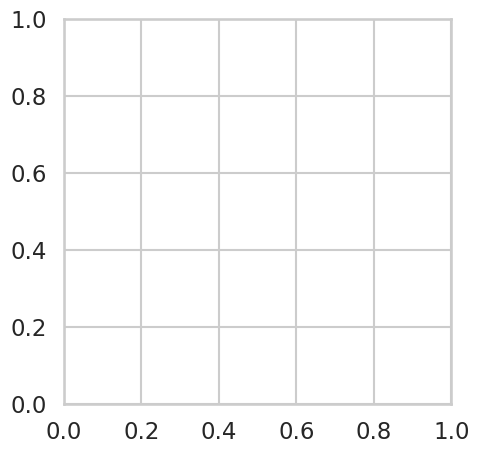